BUILDING A NEURAL NETWORK WITH TENSORFLOW & KERAS
1. From Theory to Practical
In the previous session, we learned the fundamentals of Neural Networks:
Neuron → Weights → Bias → Activation → Loss → Backpropagation → Weight Update
Now, we will take those concepts and build an actual Neural Network using Python.
Our goal is to understand:
How do we convert Neural Network theory into actual code?


2. What is TensorFlow?
TensorFlow is an open-source Machine Learning and Deep Learning library developed by Google.
It provides tools to:
• Build Neural Networks
• Train Neural Networks
• Evaluate models
• Make predictions
Simple Understanding
Think of TensorFlow as a tool/framework that helps us create and train Deep Learning models.
We don't have to manually write all the mathematical operations for:
Weights → Forward Pass → Loss → Backpropagation → Weight Updates
TensorFlow handles these operations for us.


3. What is Keras?
Keras is a high-level API integrated with TensorFlow.
It makes building Neural Networks easier by providing simple functions for:
• Creating layers
• Building models
• Training models
• Evaluating models
• Making predictions
Simple Understanding
Think of it like this:
TensorFlow → Deep Learning engine
Keras → Easy interface for building Neural Networks
So, in our code:
TensorFlow + Keras → Build and Train Neural Network


4. What Problem Are We Solving?
Now we will use the Iris Dataset.
Our goal is to predict the species of an Iris flower based on its measurements.
There are 3 species:
Setosa
Versicolor
Virginica


5. Understanding the Dataset
Each flower has four measurements:
• Sepal Length
• Sepal Width
• Petal Length
• Petal Width
These are our Input Features (X).
The flower species is our Target (y).
Simple Flow
Flower Measurements
↓
Neural Network
↓
Flower Species
In Simple Terms
We give the model the measurements of a flower and ask:
"Which type of Iris flower is this?"


6. Import Required Libraries
We first import the tools required for our project.


In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt


We don't need to memorize every import.
The important ones are:
TensorFlow/Keras → Build the Neural Network
Scikit-learn → Dataset and data preprocessing
Matplotlib → Visualize training results


7. Load the Iris Dataset


In [2]:
iris = load_iris()

X = iris.data
y = iris.target.reshape(-1, 1)


X
Contains the input features:
Sepal Length, Sepal Width, Petal Length, Petal Width
y
Contains the target class:
0, 1, 2
These numbers represent the three Iris species.
Remember
X = Input
y = Output / Target


8. One-Hot Encoding
Our target currently contains:
0, 1, 2
We convert these values into a format suitable for multi-class classification.


In [3]:
encoder = OneHotEncoder(sparse_output=False)

y_encoded = encoder.fit_transform(y)


Example
0 → [1, 0, 0]

1 → [0, 1, 0]

2 → [0, 0, 1]
This is called One-Hot Encoding.
Why?
Because we have three different classes, and our output layer will produce a probability for each class.


9. Train-Test Split
Now we divide our data into training and testing data.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42
)


Here:
80% → Training Data
20% → Testing Data
Why?
The model learns from the training data.
Then we test it using data that it has not used for training.
Simple Flow
Dataset
↓
80% Training | 20% Testing


10. Building the Neural Network
Now we create our actual Neural Network.


In [5]:
model = Sequential([
    Dense(10, input_shape=(X.shape[1],), activation='relu'),
    Dense(8, activation='relu'),
    Dense(y_encoded.shape[1], activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


This is the most important part.
Let's understand it layer by layer.


11. Sequential Model
model = Sequential([
Sequential means we are creating the Neural Network layer by layer in a sequence.
Our flow will be:
Input → Hidden Layer → Hidden Layer → Output


12. First Hidden Layer


In [6]:
Dense(10, input_shape=(X.shape[1],), activation='relu')


<Dense name=dense_3, built=False>

This creates a Dense layer with 10 neurons.
Our Iris dataset has:
4 input features
So the flow is:
4 Inputs → 10 Neurons
The activation function is:
ReLU
We learned ReLU in the previous session.


13. Second Hidden Layer


In [7]:
Dense(8, activation='relu')


<Dense name=dense_4, built=False>

This creates another Dense layer containing:
8 neurons
Again, we use:
ReLU
So now our network looks like:
4 Inputs → 10 Neurons → 8 Neurons


14. Output Layer


In [8]:
Dense(y_encoded.shape[1], activation='softmax')

<Dense name=dense_5, built=False>

We have:
3 Iris Classes
Therefore, the output layer contains:
3 neurons
The activation function is:
Softmax
Why Softmax?
Because this is a multi-class classification problem.
The three output neurons represent:
Setosa
Versicolor
Virginica
Softmax gives probability-like values for these classes.
Example
Setosa      → 0.05
Versicolor  → 0.90
Virginica   → 0.05
The highest value is:
Versicolor
Therefore, the model predicts:
Versicolor


15. Our Complete Neural Network
The complete architecture is:
Input
4 Features
    ↓
10 Neurons
ReLU
    ↓
8 Neurons
ReLU
    ↓
3 Neurons
Softmax
    ↓
Iris Species
Or simply:
4 → 10 → 8 → 3
This is the actual Neural Network we are building.


16. Compile the Model
Before training, we need to tell the model how it should learn.


In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


There are three important things here:
Optimizer
Adam
The optimizer helps update the model's weights during training.
Remember:
Prediction → Loss → Weight Update


Loss Function
Categorical Cross-Entropy
We use this because our problem is:
Multi-Class Classification
with:
One-Hot Encoded Targets


Metric
Accuracy
Accuracy tells us how many predictions are correct.
Example:
If 90 out of 100 predictions are correct:
Accuracy = 90%


17. Train the Model
Now we train our Neural Network.


In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=8,
    verbose=1
)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2812 - loss: 1.9714 - val_accuracy: 0.5000 - val_loss: 1.5044
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2812 - loss: 1.7878 - val_accuracy: 0.5000 - val_loss: 1.3955
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2812 - loss: 1.6174 - val_accuracy: 0.5000 - val_loss: 1.3003
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2812 - loss: 1.4904 - val_accuracy: 0.5000 - val_loss: 1.2257
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2812 - loss: 1.3872 - val_accuracy: 0.5000 - val_loss: 1.1628
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2812 - loss: 1.3061 - val_accuracy: 0.5000 - val_loss: 1.1159
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2812 - loss: 1.2434 - val_accuracy: 0.5000 - val_loss: 1.0858
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2812 - loss: 1.1941 - val_accuracy: 0.5000 - val_loss

The most important function here is:
model.fit()
It means:
Train the Neural Network using the training data.


18. What is an Epoch?
epochs=50
An epoch means one complete pass through the training data.
Here:
50 Epochs = The model gets 50 opportunities to learn from the training data.
During training, the model repeatedly:
Makes Prediction → Calculates Loss → Updates Weights


19. What is Batch Size?


In [11]:
batch_size=8


Instead of processing the entire training dataset at once, the model processes:
8 samples at a time
Then it updates the weights and moves to the next batch.
Simple Idea
Training Data
↓
8 Samples
↓
Update Weights
↓
Next 8 Samples
↓
Update Weights


20. What is Validation Split?

In [12]:
validation_split=0.2

This keeps aside 20% of the training data for validation.
Validation helps us monitor how the model performs on data that is not being directly used for updating the weights.
So we can monitor:
Training Performance
and
Validation Performance
during training.


21. What Happens During Training?
Remember our previous theory:
Input
↓
Forward Pass
↓
Prediction
↓
Calculate Loss
↓
Backpropagation
↓
Update Weights
↓
Repeat
All of this learning process happens when we call:
model.fit()
This is where our theory becomes practical code.


22. Evaluate the Model
After training, we test the model on the test data.


In [13]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.8667 - loss: 0.4623

Test Loss: 0.4623
Test Accuracy: 0.8667


We use:
model.evaluate()
to check how well our trained model performs on unseen test data.
Example
If the output is:
Test Accuracy: 0.9333
That means:
Approximately 93.33% of the test predictions were correct.


23. Training History
During training, we stored:
history = model.fit(...)
The history object stores information about the training process.
For example:
Training Accuracy
Validation Accuracy
Training Loss
Validation Loss
We can visualize this information using graphs.


24. Accuracy Graph


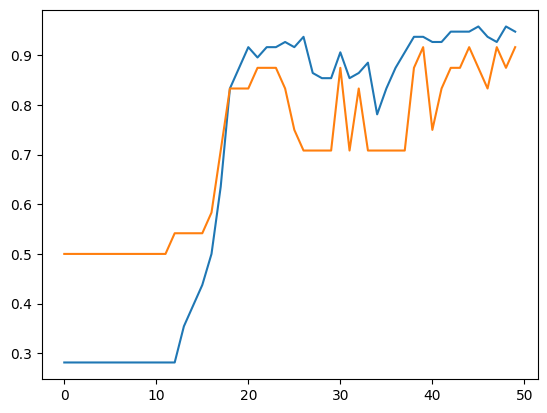

In [15]:
plt.plot(history.history['accuracy'],
         label='Train Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')


This graph shows how accuracy changes across epochs.
What do we want?
Generally, we want:
Accuracy ↑
as training progresses.
It helps us understand whether the model is learning.


25. Loss Graph

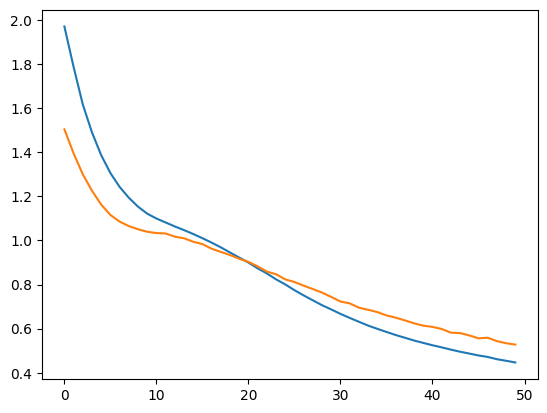

In [16]:
plt.plot(history.history['loss'],
         label='Train Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')


This graph shows how the loss changes during training.
Generally, we want:
Loss ↓
as training progresses.
Remember
Accuracy → Higher is better
Loss → Lower is better


26. Complete Workflow
Our complete Deep Learning workflow is:
Load Dataset
↓
Prepare X and y
↓
One-Hot Encode Target
↓
Train-Test Split
↓
Build Neural Network
↓
Compile Model
↓
**Train using **fit()
↓
**Evaluate using **evaluate()
↓
Visualize Accuracy & Loss


27. Connect Today's Code With Yesterday's Theory
Yesterday we learned:
Neuron
Weights
Bias
Activation
Loss
Backpropagation
Gradient Descent
Today we implemented those concepts using:
TensorFlow + Keras
We don't manually write the complete mathematics of neural-network training.
Instead, TensorFlow/Keras provides the tools to build and train the network.


QUICK REVISION
TensorFlow
A Deep Learning framework used to build and train models.
Keras
A high-level API that makes building Neural Networks easier.
Sequential
Builds a model layer by layer.
Dense
Represents a fully connected Neural Network layer.
ReLU
Activation function commonly used in hidden layers.
Softmax
Used in our output layer for multi-class classification.
One-Hot Encoding
Converts class labels into a binary vector representation.
Optimizer
Helps update the model's weights during training.
Loss Function
Measures how wrong the model's predictions are.
Epoch
One complete pass through the training data.
Batch Size
Number of samples processed before a weight update.
Fit
Trains the model.
Evaluate
Checks model performance on test data.
Accuracy
Measures the percentage of correct predictions.


KEY IDEA TO REMEMBER
Yesterday:
We learned HOW a Neural Network works.
Today:
We learned HOW to BUILD and TRAIN that Neural Network using TensorFlow and Keras.
Our Model:
4 Inputs → 10 Neurons → 8 Neurons → 3 Outputs
Complete Process:
Data → Preprocessing → Neural Network → Training → Evaluation → Results
Most Important Functions:
model = Sequential(...)
        ↓
model.compile(...)
        ↓
model.fit(...)
        ↓
model.evaluate(...)
Build → Compile → Train → Evaluate
